# Project FORESIGHT — Demand Forecasting
## Notebook 03: Machine Learning Model & Rolling Backtest

**Client:** NorthBay Living  
**Deliverable:** D3 Forecasting Model & Backtest  
**Objective:** Build, tune, backtest, and honestly compare HistGradientBoostingRegressor against the Seasonal-Naive baseline using global WAPE and Bias under zero data leakage.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Load backtest results and model metrics generated by src/forecast.py
proc_dir = Path('../data/processed')
backtest_df = pd.read_csv(proc_dir / 'backtest_results.csv')
forecast_df = pd.read_csv(proc_dir / 'forecast_results.csv')
with open(proc_dir / 'model_metrics.json') as f: 
    metrics = json.load(f)

print("Backtest dataset loaded:", backtest_df.shape)
print("Forecast dataset loaded:", forecast_df.shape)

Backtest dataset loaded: (1600, 10)
Forecast dataset loaded: (400, 15)


### 1. Honest Model Comparison: ML vs Seasonal-Naive Baseline
Evaluation across all 4 rolling origins ($1,600$ total predictions across 50 active SKUs).

In [2]:
base_m = metrics['baseline_metrics']
ml_m = metrics['ml_metrics']

comparison_table = pd.DataFrame([
    {'Model': 'Seasonal-Naive Baseline', 'WAPE (%)': base_m['wape_pct'], 'Bias (units)': base_m['bias'], 'MAE (units)': base_m['mae'], 'RMSE (units)': base_m['rmse']},
    {'Model': 'HistGradientBoosting ML', 'WAPE (%)': ml_m['wape_pct'], 'Bias (units)': ml_m['bias'], 'MAE (units)': ml_m['mae'], 'RMSE (units)': ml_m['rmse']}
])

print("=== GLOBAL BACKTEST COMPARISON ===")
display(comparison_table)

print("\n--- PER-ORIGIN WAPE BREAKDOWN ---")
orig_df = pd.DataFrame(metrics['origin_breakdown'])
display(orig_df[['origin_index', 'origin_date', 'baseline_wape', 'ml_wape', 'baseline_bias', 'ml_bias']])

print(f"\nML beats Seasonal-Naive: {metrics['ml_beats_baseline']}")
print(f"Selected Final Production Method: {metrics['selected_final_method']}")

=== GLOBAL BACKTEST COMPARISON ===


,Model,WAPE (%),Bias (units),MAE (units),RMSE (units)
0,Seasonal-Naive Baseline,11.17,0.2806,10.23,13.37
1,HistGradientBoosting ML,10.56,2.0277,9.67,12.80



--- PER-ORIGIN WAPE BREAKDOWN ---


,origin_index,origin_date,baseline_wape,ml_wape,baseline_bias,ml_bias
0,71,2025-05-12,0.100396,0.105119,0.4050,6.61675
1,79,2025-07-07,0.116899,0.111442,0.3125,1.96500
2,87,2025-09-01,0.113703,0.103030,0.2050,-0.82575
3,95,2025-10-27,0.118717,0.102591,0.2000,0.35475



ML beats Seasonal-Naive: True
Selected Final Production Method: HistGradientBoostingRegressor


### 2. Forward 8-Week Demand Forecast
Review forward 8-week predictions with calibrated 80% prediction intervals.

In [3]:
print(f"Total Forward Predictions: {len(forecast_df)} rows ({forecast_df['SKU'].nunique()} SKUs x 8 weeks)")
print(f"Forecast Weeks: {forecast_df['Forecast_Week'].min()} to {forecast_df['Forecast_Week'].max()}")
print(f"Total Forecast Demand: {forecast_df['Forecast_Units'].sum():,.1f} units")
print(f"Total Projected 8-Week Revenue: INR {forecast_df['Forecast_Revenue'].sum():,.2f}")

print("\nSample Forward Forecast (SKU012 - Product 012):")
display(forecast_df[forecast_df['SKU'] == 'SKU012'][['Forecast_Week', 'Horizon_Step', 'Forecast_Units', 'Interval_P10', 'Interval_P90', 'Forecast_Revenue']])

Total Forward Predictions: 400 rows (50 SKUs x 8 weeks)
Forecast Weeks: 2025-12-29 to 2026-02-16
Total Forecast Demand: 39,504.9 units
Total Projected 8-Week Revenue: INR 240,887,959.57

Sample Forward Forecast (SKU012 - Product 012):


,Forecast_Week,Horizon_Step,Forecast_Units,Interval_P10,Interval_P90,Forecast_Revenue
11,2025-12-29,1,174.8,167.9,182.0,1534633.88
61,2026-01-05,2,173.7,166.8,180.9,1524976.57
111,2026-01-12,3,179.5,172.6,186.7,1575896.92
161,2026-01-19,4,181.3,174.4,188.5,1591699.78
211,2026-01-26,5,186.8,179.9,194.0,1639986.32
261,2026-02-02,6,197.6,190.7,204.8,1734803.51
311,2026-02-09,7,202.8,195.9,210.0,1780456.24
361,2026-02-16,8,205.4,198.5,212.6,1803282.60


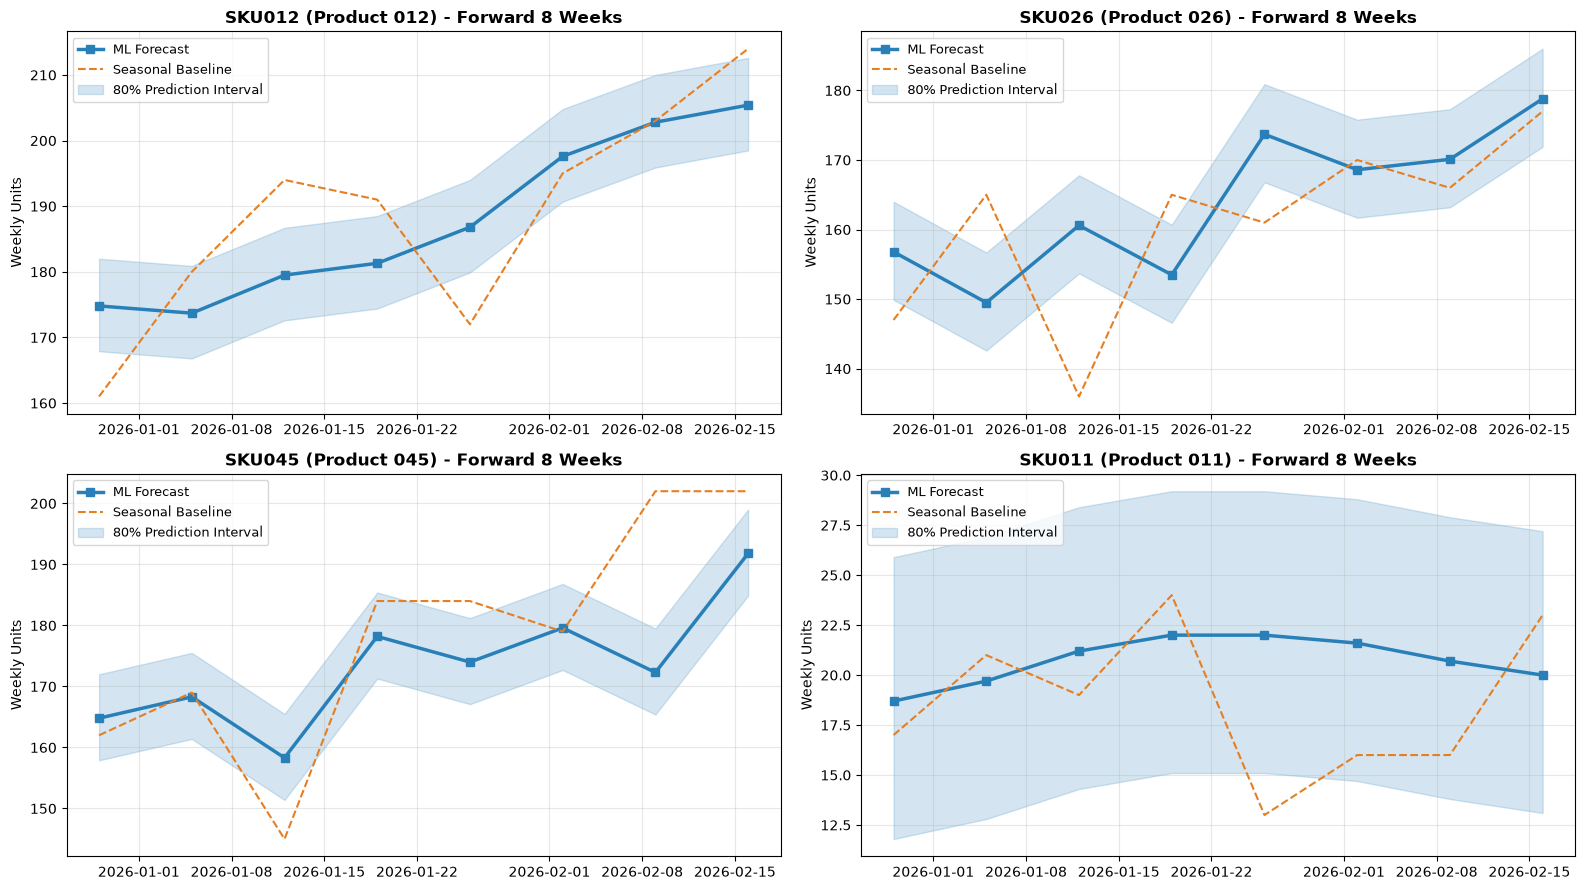

In [4]:
# Visualizing Forward 8-Week Forecast for Representative SKUs
rep_skus = ['SKU012', 'SKU026', 'SKU045', 'SKU011']
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, sku in enumerate(rep_skus):
    ax = axes[i]
    sku_sub = forecast_df[forecast_df['SKU'] == sku].sort_values(by='Horizon_Step')
    dates = pd.to_datetime(sku_sub['Forecast_Week'])
    
    ax.plot(dates, sku_sub['Forecast_Units'], label='ML Forecast', color='#2980b9', lw=2.5, marker='s')
    ax.plot(dates, sku_sub['Baseline_Units'], label='Seasonal Baseline', color='#e67e22', ls='--', lw=1.5)
    ax.fill_between(dates, sku_sub['Interval_P10'], sku_sub['Interval_P90'], color='#2980b9', alpha=0.2, label='80% Prediction Interval')
    
    ax.set_title(f"{sku} ({sku_sub['Product_Name'].iloc[0]}) - Forward 8 Weeks", fontweight='bold')
    ax.set_ylabel('Weekly Units')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()